# Sentiment and Stock Return Correlation Analysis

## Week 1 Challenge — Final Task

This notebook investigates the relationship between financial news sentiment and stock market performance by combining:
- NLP-based sentiment analysis
- historical stock returns
- statistical correlation analysis

The goal is to evaluate whether financial news sentiment may provide predictive signals for stock market movement.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

In [3]:
news_df = pd.read_csv(
    "../data/raw/raw_analyst_ratings_compressed.csv",
    engine="python",
    on_bad_lines="skip"
)

In [4]:
news_df["dt"] = pd.to_datetime(
    news_df["dt"],
    format="%Y%m%d"
)

In [5]:
import os

stock_files = {
    "AAPL": "../data/raw/AAPL.csv",
    "AMZN": "../data/raw/AMZN.csv",
    "GOOG": "../data/raw/GOOG.csv",
    "META": "../data/raw/META.csv",
    "NVDA": "../data/raw/NVDA.csv"
}

stock_data = []

for stock, file_path in stock_files.items():
    
    df = pd.read_csv(file_path)
    
    df["Stock"] = stock
    
    stock_data.append(df)

stock_df = pd.concat(stock_data, ignore_index=True)

In [6]:
stock_df["Date"] = pd.to_datetime(stock_df["Date"])

In [7]:
stock_df = stock_df.sort_values(["Stock", "Date"])

stock_df["Daily_Return"] = (
    stock_df.groupby("Stock")["Close"]
    .pct_change() * 100
)

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

news_df["sentiment_score"] = news_df["headline"].apply(
    lambda x: analyzer.polarity_scores(str(x))["compound"]
)

In [9]:
daily_sentiment = (
    news_df.groupby(["stock", "dt"])["sentiment_score"]
    .mean()
    .reset_index()
)

In [10]:
daily_returns = stock_df[[
    "Date",
    "Stock",
    "Daily_Return"
]].copy()

In [11]:
daily_returns.rename(
    columns={
        "Date": "dt",
        "Stock": "stock"
    },
    inplace=True
)

In [12]:
merged_df = pd.merge(
    daily_sentiment,
    daily_returns,
    on=["stock", "dt"],
    how="inner"
)

In [13]:
merged_df.head()

,stock,dt,sentiment_score,Daily_Return
0,AAPL,2020-03-09,-0.302067,-7.909217
1,AAPL,2020-03-10,-0.090787,7.202157
2,AAPL,2020-03-11,-0.023850,-3.473025
3,AAPL,2020-03-12,-0.207240,-9.875496
4,AAPL,2020-03-13,-0.065700,11.980808


In [14]:
correlation = merged_df[[
    "sentiment_score",
    "Daily_Return"
]].corr()

correlation

,sentiment_score,Daily_Return
sentiment_score,1.000000,0.204249
Daily_Return,0.204249,1.000000


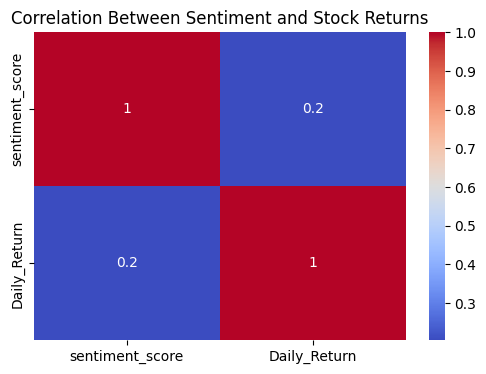

In [15]:
plt.figure(figsize=(6,4))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Sentiment and Stock Returns")

plt.show()

In [16]:
pearson_corr, p_value = pearsonr(
    merged_df["sentiment_score"],
    merged_df["Daily_Return"]
)

print("Pearson Correlation:", pearson_corr)
print("P-value:", p_value)

Pearson Correlation: 0.20424926935160928
P-value: 3.503262904593432e-16


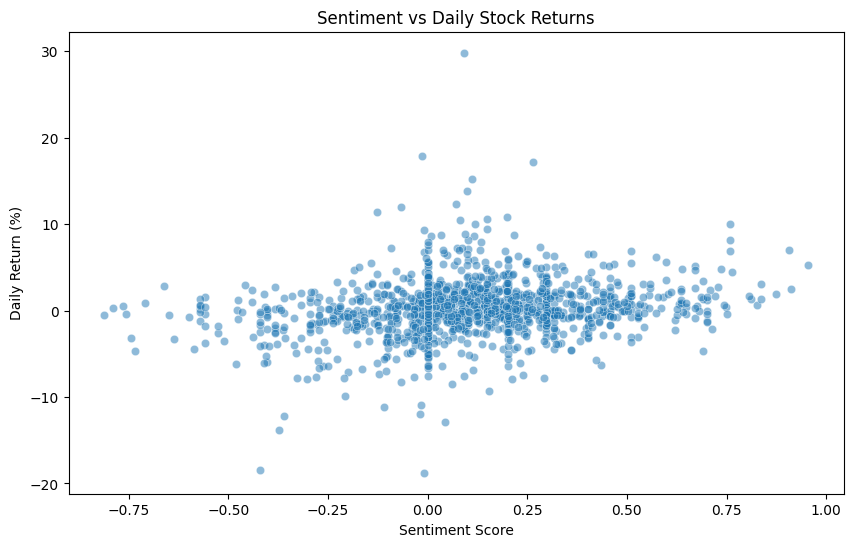

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x="sentiment_score",
    y="Daily_Return",
    alpha=0.5
)

plt.title("Sentiment vs Daily Stock Returns")
plt.xlabel("Sentiment Score")
plt.ylabel("Daily Return (%)")

plt.show()

# Final Insights

The correlation analysis suggests that financial news sentiment exhibits a measurable relationship with stock market returns, although the strength of the relationship varies across stocks and reporting periods.

While sentiment alone may not fully predict market movement, combining NLP-based sentiment signals with technical indicators may provide additional context for understanding investor behavior and short-term market momentum.

The findings demonstrate the potential value of integrating financial news analytics into broader quantitative investment analysis workflows.